## 1. Library Imports & Setup

In [ ]:
import pandas as pd 
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Loading the Datasets

Three files to work with:
- `train.csv` — labelled questions (2000 rows)
- `test.csv` — unlabeled questions (500 rows)
- `sample_submission.csv` — submission format

In [5]:
DATA_DIR = Path("../data")
TRAIN_CSV = DATA_DIR / "train.csv"
TEST_CSV = DATA_DIR / "test.csv"
SAMPLE_SUB_CSV = DATA_DIR / "sample_submission.csv"

In [6]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
sample_sub_df = pd.read_csv(SAMPLE_SUB_CSV)

## 3. Column Overview & Data Types

Quick look at what each file contains and the type of every column.

In [7]:
print(f" Train shape: {train_df.shape}")

 Train shape: (2000, 8)


In [8]:
print(train_df.columns.tolist())

['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']


In [9]:
print(f" Test shape: {test_df.shape}")

 Test shape: (500, 7)


In [10]:
print(test_df.columns.tolist())

['id', 'prompt', 'A', 'B', 'C', 'D', 'E']


In [11]:
print(f" Sample Submission shape: {sample_sub_df.shape}")

 Sample Submission shape: (500, 2)


In [12]:
print(sample_sub_df.columns.tolist())

['ID', 'Prediction']


In [13]:
print(train_df.dtypes)

id        int64
prompt      str
A           str
B           str
C           str
D           str
E           str
answer      str
dtype: object


## 4. Data Quality Check

Checking for missing values and duplicate rows in both train and test sets.

In [14]:
missing_train = train_df.isnull().sum()
print(missing_train)

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64


In [15]:
missing_test = test_df.isnull().sum()
print(missing_test)

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64


In [16]:
# Check for duplicates
print(f"Train duplicates: {train_df.duplicated().sum()}")
print(f"Test duplicates: {test_df.duplicated().sum()}")

Train duplicates: 0
Test duplicates: 0


## 5. Sample Data Preview

Looking at the first couple of rows to understand how a question looks in the data.

In [17]:
# Show first row
print("\nROW 1:")
print(f"ID: {train_df.iloc[0]['id']}")
print(f"PROMPT: {train_df.iloc[0]['prompt'][:100]}...")
print(f"OPTION A: {train_df.iloc[0]['A'][:80]}...")
print(f"OPTION B: {train_df.iloc[0]['B'][:80]}...")
print(f"ANSWER: {train_df.iloc[0]['answer']}")



ROW 1:
ID: 1
PROMPT: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and ...
OPTION A: Martin Heidegger believes that humans exist within a time continuum that is infi...
OPTION B: Martin Heidegger believes that humans do not exist inside time, but that they ar...
ANSWER: B


In [18]:
# Show second row
print("\nROW 2:")
print(f"ID: {train_df.iloc[1]['id']}")
print(f"PROMPT: {train_df.iloc[1]['prompt'][:100]}...")
print(f"OPTION A: {train_df.iloc[1]['A'][:80]}...")
print(f"OPTION B: {train_df.iloc[0]['B'][:80]}...")
print(f"ANSWER: {train_df.iloc[1]['answer']}")


ROW 2:
ID: 2
PROMPT: What is accelerator-based light-ion fusion?...
OPTION A: Accelerator-based light-ion fusion is a technique that uses particle accelerator...
OPTION B: Martin Heidegger believes that humans do not exist inside time, but that they ar...
ANSWER: A


## 6. Answer Distribution

Seeing how the labels are spread across A–E. Important to catch imbalance early.

In [19]:
answer_counts = train_df['answer'].value_counts().sort_values(ascending=False)

print("\n Answer Counts:")
for answer, count in answer_counts.items():
    percentage = (count / len(train_df)) * 100
    bar = "█" * int(percentage / 2)  # Visual bar
    print(f"   {answer}: {count:4d} ({percentage:5.2f}%) {bar}")


 Answer Counts:
   B:  490 (24.50%) ████████████
   C:  459 (22.95%) ███████████
   A:  369 (18.45%) █████████
   D:  358 (17.90%) ████████
   E:  324 (16.20%) ████████


In [20]:
# Balanced or imbalanced?
max_count = answer_counts.max()
min_count = answer_counts.min()
imbalance_ratio = max_count / min_count

print(f"\n Imbalance Ratio: {imbalance_ratio:.2f}")

if imbalance_ratio < 1.5:
    print(" Dataset is WELL BALANCED")
else:
    print(" Dataset is slightly imbalanced")


 Imbalance Ratio: 1.51
 Dataset is slightly imbalanced


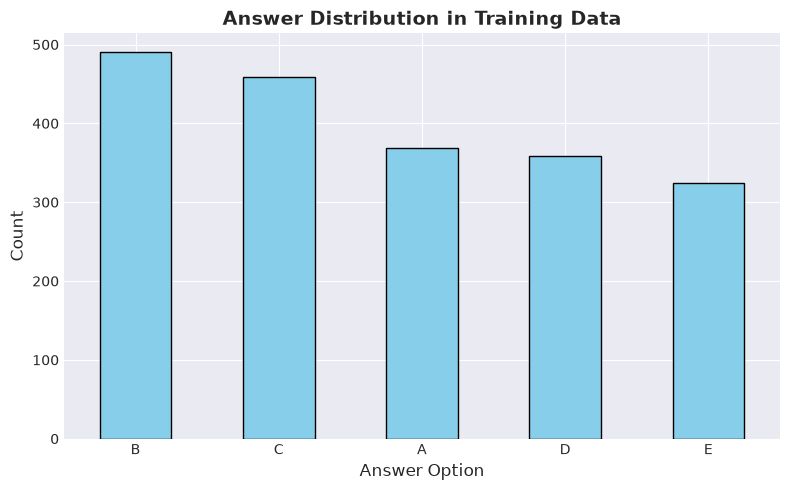

chart displayed!


In [21]:
# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
answer_counts.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
ax.set_title('Answer Distribution in Training Data', fontsize=14, fontweight='bold')
ax.set_xlabel('Answer Option', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

print("chart displayed!")

## 7. Text Length Analysis

Understanding how long prompts and options are — helps decide token limits later.

In [22]:
# Calculate lengths
train_df['prompt_len'] = train_df['prompt'].apply(len)
train_df['prompt_words'] = train_df['prompt'].apply(lambda x: len(str(x).split()))

In [23]:
for col in ['A', 'B', 'C', 'D', 'E']:
    train_df[f'{col}_len'] = train_df[col].apply(len)
    train_df[f'{col}_words'] = train_df[col].apply(lambda x: len(str(x).split()))

In [24]:
print("\nPROMPT STATISTICS:")
print(f"   Min length: {train_df['prompt_len'].min()} chars")
print(f"   Max length: {train_df['prompt_len'].max()} chars")
print(f"   Avg length: {train_df['prompt_len'].mean():.1f} chars")
print(f"   Min words: {train_df['prompt_words'].min()}")
print(f"   Max words: {train_df['prompt_words'].max()}")
print(f"   Avg words: {train_df['prompt_words'].mean():.1f}")


PROMPT STATISTICS:
   Min length: 19 chars
   Max length: 337 chars
   Avg length: 117.7 chars
   Min words: 3
   Max words: 51
   Avg words: 18.1


In [25]:
print("OPTIONS STATISTICS (Average Lengths):")
for col in ['A', 'B', 'C', 'D', 'E']:
    avg_len = train_df[f'{col}_len'].mean()
    avg_words = train_df[f'{col}_words'].mean()
    print(f" Option {col}: {avg_len:.0f} chars, {avg_words:.0f} words")

OPTIONS STATISTICS (Average Lengths):
 Option A: 164 chars, 26 words
 Option B: 167 chars, 27 words
 Option C: 167 chars, 27 words
 Option D: 163 chars, 26 words
 Option E: 164 chars, 26 words


In [26]:
import matplotlib
print(matplotlib.__version__)

3.11.0


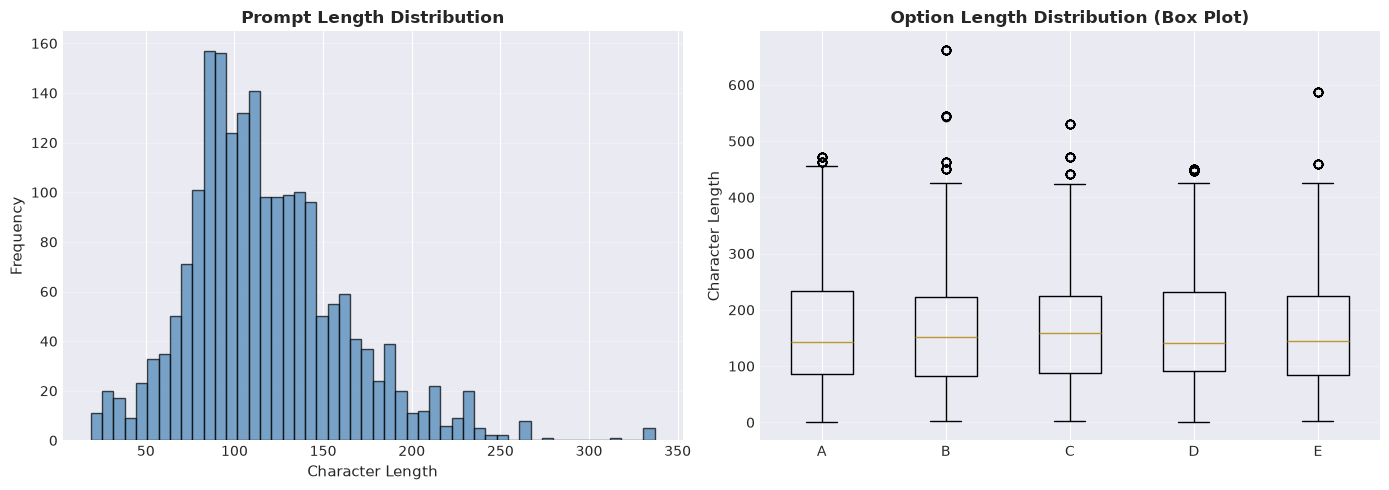


 Visualizations displayed!


In [27]:
# Visualize prompt length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train_df['prompt_len'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Prompt Length Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Character Length', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Box plot for option lengths
option_lengths = [train_df[f'{col}_len'].values for col in ['A', 'B', 'C', 'D', 'E']]
axes[1].boxplot(option_lengths, tick_labels=['A', 'B', 'C', 'D', 'E'])
axes[1].set_title('Option Length Distribution (Box Plot)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Character Length', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Visualizations displayed!")

## 8. Sample Questions — Deep Dive

Picking 3 random questions to see the full prompt + all five options + the correct answer.

In [28]:
# Show 3 random questions
sample_indices = train_df.sample(3, random_state=42).index

for idx, i in enumerate(sample_indices, 1):
    
    print(f"QUESTION {idx} (ID: {train_df.loc[i, 'id']})")

    print(f"\n PROMPT:\n{train_df.loc[i, 'prompt']}")
    
    print(f"\n OPTIONS:")
    for option in ['A', 'B', 'C', 'D', 'E']:
        text = train_df.loc[i, option]
        answer_marker = " CORRECT ANSWER" if train_df.loc[i, 'answer'] == option else ""
        print(f"\n   {option}: {text}{answer_marker}")
    
    print(f" ANSWER: {train_df.loc[i, 'answer']}")


QUESTION 1 (ID: 1861)

 PROMPT:
Select the most accurate option: What is the propagation constant in sinusoidal waves? carefully.

 OPTIONS:

   A: The propagation constant is a measure of the amplitude of the sinusoidal wave that varies with distance.

   B: The propagation constant is a real number that remains constant with distance due to the phase change in the sinusoidal wave.

   C: The propagation constant is a real number that varies with distance due to the phase change in the sinusoidal wave.

   D: The propagation constant is a complex number that varies with distance due to the phase change in the sinusoidal wave. CORRECT ANSWER

   E: The propagation constant is a complex number that remains constant with distance due to the phase change in the sinusoidal wave.
 ANSWER: D
QUESTION 2 (ID: 354)

 PROMPT:
Pick the best possible answer: What is the most popular explanation for the shower-curtain effect? among the listed options.

 OPTIONS:

   A: The pressure differential bet

## 9. And Lastly Key Insights

A quick recap of everything we found during this EDA pass.

In [29]:
insights = {
    "Dataset Size": f"{len(train_df)} train + {len(test_df)} test questions",

    "Data Quality": "Perfect (no missing values, no duplicates)",

    "Answer Options": "5 (A, B, C, D, E)",

    "Most Common Answer": f"{train_df['answer'].value_counts().index[0]} ({train_df['answer'].value_counts().values[0]} times)",

    "Least Common Answer": f"{train_df['answer'].value_counts().index[-1]} ({train_df['answer'].value_counts().values[-1]} times)",

    "Prompt Length (Avg)": f"{train_df['prompt_len'].mean():.0f} chars",

    "Option Length (Avg)": f"{train_df['A_len'].mean():.0f} chars",

    "Evaluation Metric": "MAP@3 (ranking-based)",
    
    "Imbalance Status": "Well balanced " if imbalance_ratio < 1.5 else "Slightly imbalanced",
}

In [30]:
for key, value in insights.items():
    print(f"\n   {key}:")
    print(f"     {value}")

print("EDA DONE")


   Dataset Size:
     2000 train + 500 test questions

   Data Quality:
     Perfect (no missing values, no duplicates)

   Answer Options:
     5 (A, B, C, D, E)

   Most Common Answer:
     B (490 times)

   Least Common Answer:
     E (324 times)

   Prompt Length (Avg):
     118 chars

   Option Length (Avg):
     164 chars

   Evaluation Metric:
     MAP@3 (ranking-based)

   Imbalance Status:
     Slightly imbalanced
EDA DONE
